### 종합과제 1 - 중고차 가격 예측 모델 기반 스타트업 Pos Cars의 인도 중고차 시장 진입 전략 제안 프로젝트


## 0.문제정의



분석 주제: 스타트업 Pos Cars(주) 회사의 인도 중고차 시장 진입을 위해 중고차 가격 결정 요인을 분석하고, 이를 바탕으로 적정 가격을 예측할 수 있는 모델을 개발한다.


세부 주제 :  
- 중고차 가격에 영향을 미치는 핵심 인자 도출
- 중고차 적정 가격 예측 모델 및 모델 향상 방안
   
    => 인도 중고차 시장 기회 요인 탐색   


분석 배경: 실습 목적으로 진행하는 이 프로젝트는, 제한된 시장 조사 리소스를 감안하여, 기존에 접근 가능한 데이터를 활용해 인도 중고차 시장의 기회 요인을 탐색하고, 이를 토대로 중고차 가격 예측 모델을 개발함으로써, 중고차 판매 서비스에 활용할 수 있는 전략을 제안하고자 한다.


## 1.데이터 불러오기

In [ ]:
#라이브러리 설치
import pandas as pd
import numpy as np
import graphviz
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats
import warnings

from statsmodels.formula.api import ols
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import export_graphviz
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import qqplot, add_constant
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 환경에서는 'Malgun Gothic' 폰트를 사용
else:
    plt.rcParams['font.family'] = 'sans-serif'  # macOS나 Linux 등 다른 환경에서는 'AppleGothic' 폰트를 사용

matplotlib.rcParams['axes.unicode_minus'] = False

In [ ]:
#맥 전용 폰트 코드
from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False
# matplotlib의 폰트를 설정합니다.
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'
# 한글 지원 폰트 중에서 사용 가능한 것을 선택하여 추가합니다. 여기서는 'NanumBarunGothic'을 사용합니다.
# 시스템에 따라 설치되어 있는 폰트명을 사용해야 합니다.
plt.rcParams['font.sans-serif'] = 'NanumBarunGothic', 'Malgun Gothic', 'DejaVu Sans'  # 여기에 사용 가능한 폰트 추가

In [ ]:
#파일 불러오기
df = pd.read_csv('/content/drive/MyDrive/최강<포빅아A4>/인도 중고차 /Car.csv')
df.head()

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,CNG,Manual,First,26.6 kmpl,998 CC,58.16 bhp,5.0,NaN
1,Hyundai Creta 1.6 CRDi SX Option,Pune,19162.00,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN
2,Honda Jazz V,Chennai,6898.32,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh
3,Maruti Ertiga VDI,Chennai,9197.76,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,27194.71,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN


## 2.변수 정의 확인

In [ ]:
# 변수 타입 어떤 의미인지 계속 체크용
# 계속 위로 올라가서 보기 번거로우니까 노션에 컬럼 의미 캡쳐한 사진 옆에 띄워놓고 보기

**> 목표변수**
- Price 중고차 가격(단위 : 1,000원)

**> 설명변수**
- Name : 자동차 브랜드와 모델의 이름
- Location : 자동차를 팔거나 구매할 수 있는 위치
    - 총 11개 인도 주요 도시
- Year : 모델의 년도 혹은 버전
- Kilometers_Driven : 이전 소유주의 차량 주행거리(Km)
- Fuel_Type : 자동차의 사용연료의 종류
    - 총 5개 타입
- Transmission : 자동차의 사용 변속기 종류
    - 총 2개 타입
- Owner_Type : 소유권이 직접 소유인지, 중고 소유인지 여부
    - 총 4개 타입
- Mileage : 자동차 회사가 제공하는 표준주행거리(kmpl)
- Engine : 엔진의 배기량(cc)
- Power : 엔진의 최대 출력(bhp)
- Seats : 차의 좌석 수
- New_Price : 뉴 모델의 가격


In [ ]:
# 명목형 변수 목록
obj_cols = df.select_dtypes("object").columns

for col in obj_cols:
    _n = len(df[col].value_counts())
    print(col, ":", str(_n))

Name : 2041
Location : 11
Fuel_Type : 5
Transmission : 2
Owner_Type : 4
Mileage : 438
Engine : 150
Power : 386
New_Price : 625


In [ ]:
# 명목형 변수 별 분류 집단 확인
# 아래 이외의 변수들은 숫자형 변수인데 단위 처리하거나 문자열로 입력되어서 개별 처리해줘야 할 목록들

In [ ]:
df['Location'].unique()

array(['Mumbai', 'Pune', 'Chennai', 'Coimbatore', 'Hyderabad', 'Jaipur',
       'Kochi', 'Kolkata', 'Delhi', 'Bangalore', 'Ahmedabad'],
      dtype=object)

In [ ]:
df['Fuel_Type'].unique()

array(['CNG', 'Diesel', 'Petrol', 'LPG', 'Electric'], dtype=object)

In [ ]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [ ]:
df['Owner_Type'].unique()

array(['First', 'Second', 'Fourth & Above', 'Third'], dtype=object)

## 3.데이터 정보 확인

In [ ]:
df.shape #총 7253개 데이터 , 13개 컬럼

(7253, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               7253 non-null   object 
 1   Location           7253 non-null   object 
 2   Price              6200 non-null   float64
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 736.8+ KB


In [ ]:
#결측치 확인
df.isnull().sum()

Name                    0
Location                0
Price                1053
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
dtype: int64

* price 에서 약 1,000개의 결측치 확인
* mileage , engine , power, seats
* new_price는 데이터의 약 90%이상이 결측치

In [ ]:
#목표변수(연속형 변수) 기술통계량 확인
df['Price'].describe()

count      6200.000000
mean      14912.514750
std       17674.318464
min           7.080000
25%        5365.360000
50%        8814.520000
75%       15869.972500
max      245273.600000
Name: Price, dtype: float64

평균 대비 max값이 약 10배 이상인 것으로 보아 극단값이 존재하는 것으로 보임.
Price 변수에 대한 결측치 및 이상치 처리 필요

In [ ]:
df.describe()

,Price,Year,Kilometers_Driven,Seats
count,6200.000000,7253.000000,7.253000e+03,7200.000000
mean,14912.514750,2013.365366,5.869906e+04,5.279722
std,17674.318464,3.254421,8.442772e+04,0.811660
min,7.080000,1996.000000,1.710000e+02,0.000000
25%,5365.360000,2011.000000,3.400000e+04,5.000000
50%,8814.520000,2014.000000,5.341600e+04,5.000000
75%,15869.972500,2016.000000,7.300000e+04,5.000000
max,245273.600000,2019.000000,6.500000e+06,10.000000


* seats min 값이 0 => 좌석 수가 0으로 체크된 것으로 보아 잘못 입력된 값이 있어 보임 ,처리 필요
* Year => 1996년 ~ 2019년 기반 데이터

## 4. 데이터 전처리

### 데이터 타입 변경


In [ ]:
# Mileage, Engine, Power 단위랑 분리해서 연속형 변수로 전환
df['Mileage'] = df['Mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Engine'] = df['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Power'] = df['Power'].str.extract(r'(\d+\.?\d*)').astype(float)

In [ ]:
#바뀐거 체크
df.head(1)

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,CNG,Manual,First,26.6,998.0,58.16,5.0,NaN


### 데이터 결측치 처리

* price 에서 약 1,000개의 결측치 확인
* mileage , engine , power, seats
* new_price는 데이터의 약 90%이상이 결측치


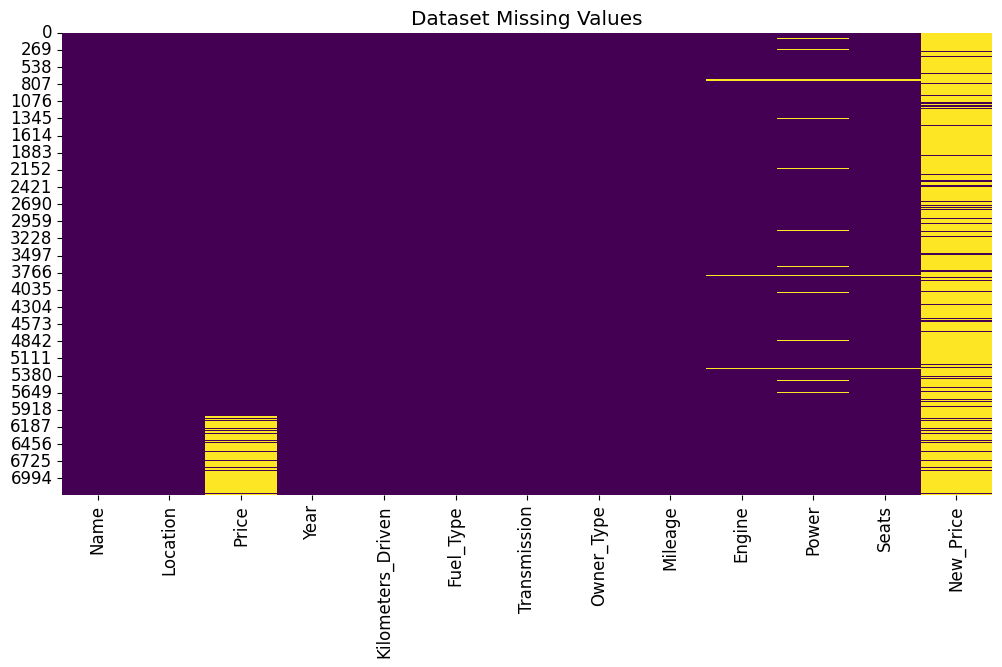

In [ ]:
# 결측치 히트맵
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Dataset Missing Values')
plt.show()

In [ ]:
# 가격 결측치가 있는 데이터 행에 대해서만 df생성
missing_price_df = df[df['Price'].isnull()]

In [ ]:
missing_price_df.head()

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
6019,Maruti Alto K10 LXI CNG,Delhi,NaN,2014,40929,CNG,Manual,First,32.26,998.0,58.20,4.0,NaN
6020,Maruti Alto 800 2016-2019 LXI,Coimbatore,NaN,2013,54493,Petrol,Manual,Second,24.70,796.0,47.30,5.0,NaN
6022,Toyota Etios Liva GD,Hyderabad,NaN,2012,139000,Diesel,Manual,First,23.59,1364.0,NaN,5.0,NaN
6023,Hyundai i20 Magna,Mumbai,NaN,2014,29000,Petrol,Manual,First,18.50,1197.0,82.85,5.0,NaN
6024,Mahindra XUV500 W8 2WD,Coimbatore,NaN,2016,85609,Diesel,Manual,Second,16.00,2179.0,140.00,7.0,NaN


6019번째 데이터부터 가격 결측치가 1,000개 분포되어 있다. 이걸 보았을 때 후반부 데이터 작업에서 가격을 입력하지 않은 실수가 있었던 것 같다.

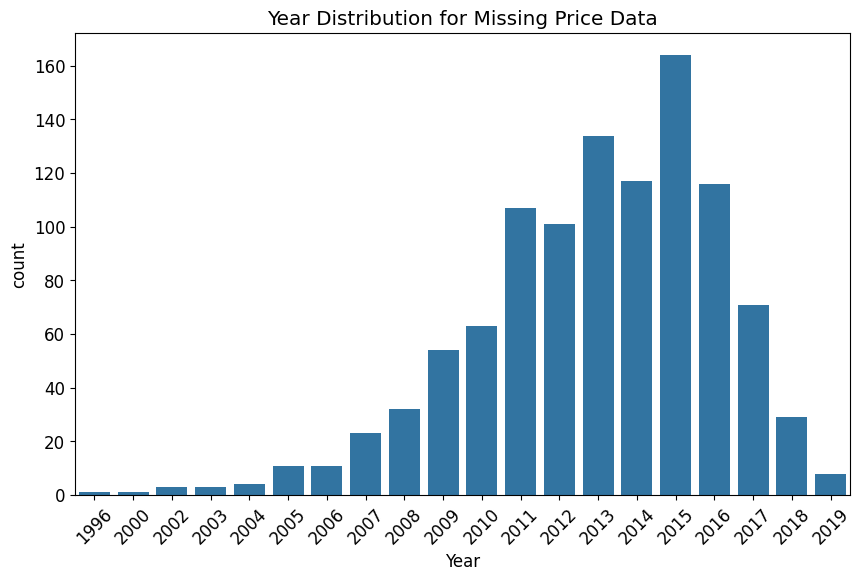

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Year', data=missing_price_df, order=sorted(missing_price_df['Year'].unique()))
plt.title('Year Distribution for Missing Price Data')
plt.xticks(rotation=45)
plt.show()

2011~2016사이에 한 해 100개 이상 결측치 존재 => 해당 년도에 무슨 일이 있었는지?

In [ ]:
# 특정 연도별 결측치 분포 확인
target_years = [2011,2012,2013, 2014, 2015]
for year in target_years:
    # 각 연도별 총 데이터 수 계산
    total_cnt = len(df[df['Year'] == year])
    print(f"{year}년 총 데이터 수: {total_cnt}")

    # 각 연도별 Price 결측치가 있는 데이터의 수 계산
    missing_cnt = len(missing_price_df[missing_price_df['Year'] == year])
    print(f"{year}년 Price 결측치 데이터 수: {missing_cnt}")


2011년 총 데이터 수: 579
2011년 Price 결측치 데이터 수: 107
2012년 총 데이터 수: 690
2012년 Price 결측치 데이터 수: 101
2013년 총 데이터 수: 791
2013년 Price 결측치 데이터 수: 134
2014년 총 데이터 수: 925
2014년 Price 결측치 데이터 수: 117
2015년 총 데이터 수: 929
2015년 Price 결측치 데이터 수: 164


In [ ]:
df[df['Year'] == 2011].info() #579개 데이터 중에 107개가 결측
missing_price_df[missing_price_df['Year'] == 2011].describe()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 579 entries, 2 to 7248
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               579 non-null    object 
 1   Location           579 non-null    object 
 2   Price              472 non-null    float64
 3   Year               579 non-null    int64  
 4   Kilometers_Driven  579 non-null    int64  
 5   Fuel_Type          579 non-null    object 
 6   Transmission       579 non-null    object 
 7   Owner_Type         579 non-null    object 
 8   Mileage            578 non-null    float64
 9   Engine             575 non-null    float64
 10  Power              565 non-null    float64
 11  Seats              575 non-null    float64
 12  New_Price          29 non-null     object 
dtypes: float64(5), int64(2), object(6)
memory usage: 63.3+ KB


,Price,Year,Kilometers_Driven,Mileage,Engine,Power,Seats
count,0.0,107.0,107.000000,107.000000,107.000000,106.000000,107.000000
mean,NaN,2011.0,69955.691589,16.748598,1674.644860,114.864057,5.242991
std,NaN,0.0,28347.021230,4.228937,596.014804,51.028806,0.737680
min,NaN,2011.0,11791.000000,0.000000,796.000000,46.300000,4.000000
25%,NaN,2011.0,51799.500000,14.105000,1198.000000,78.900000,5.000000
50%,NaN,2011.0,66287.000000,17.000000,1497.000000,102.600000,5.000000
75%,NaN,2011.0,82000.000000,19.905000,1995.000000,147.802500,5.000000
max,NaN,2011.0,157301.000000,25.440000,2993.000000,282.000000,8.000000


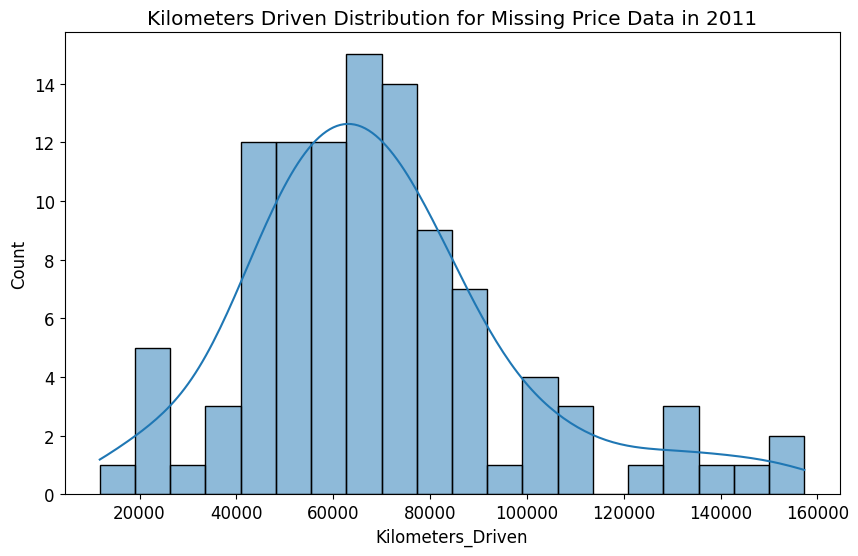

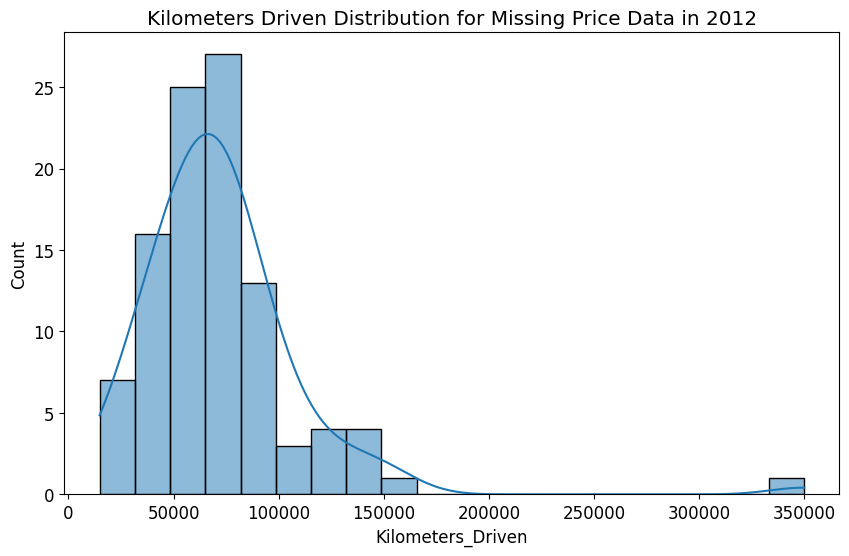

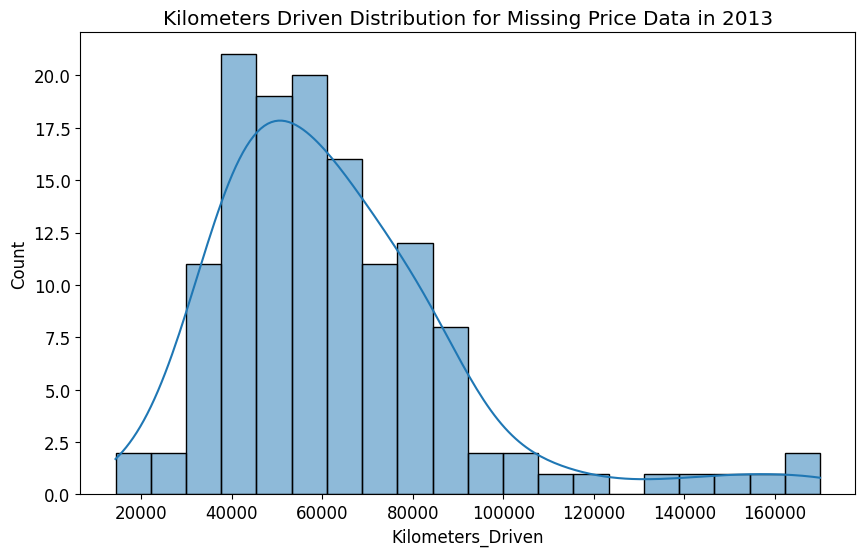

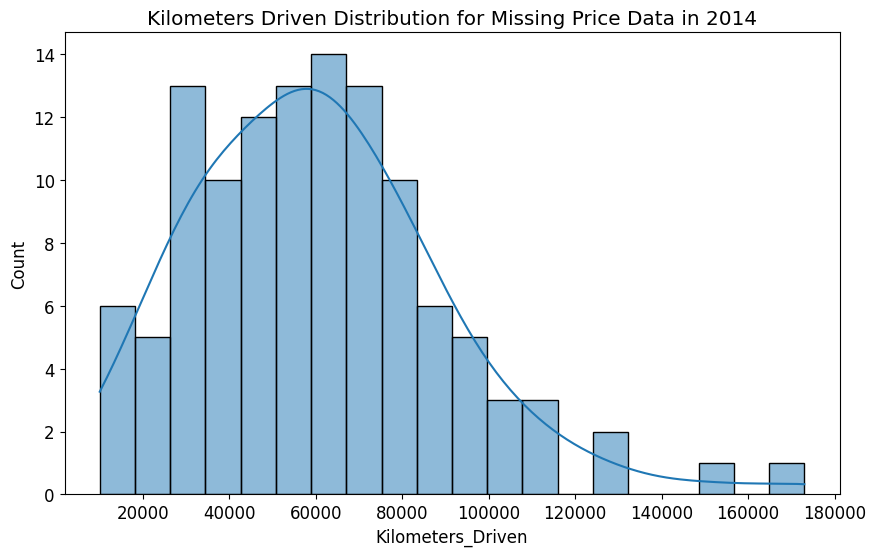

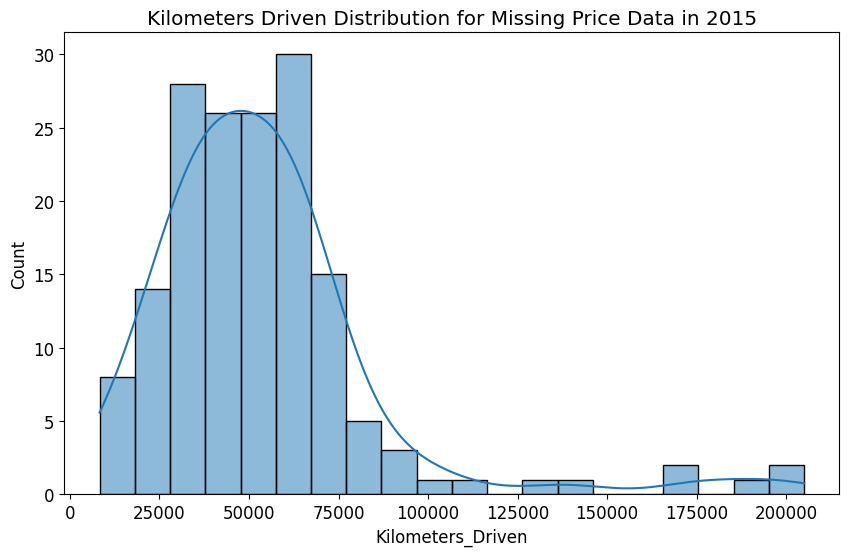

In [ ]:
# 시각화를 통한 패턴 분석
# 'Kilometers_Driven'에 대한 가격 결측치 데이터 분포
for year in target_years:
    year_data = missing_price_df[missing_price_df['Year'] == year]
    plt.figure(figsize=(10, 6))
    sns.histplot(year_data['Kilometers_Driven'], bins=20, kde=True)
    plt.title(f'Kilometers Driven Distribution for Missing Price Data in {year}')
    plt.show()


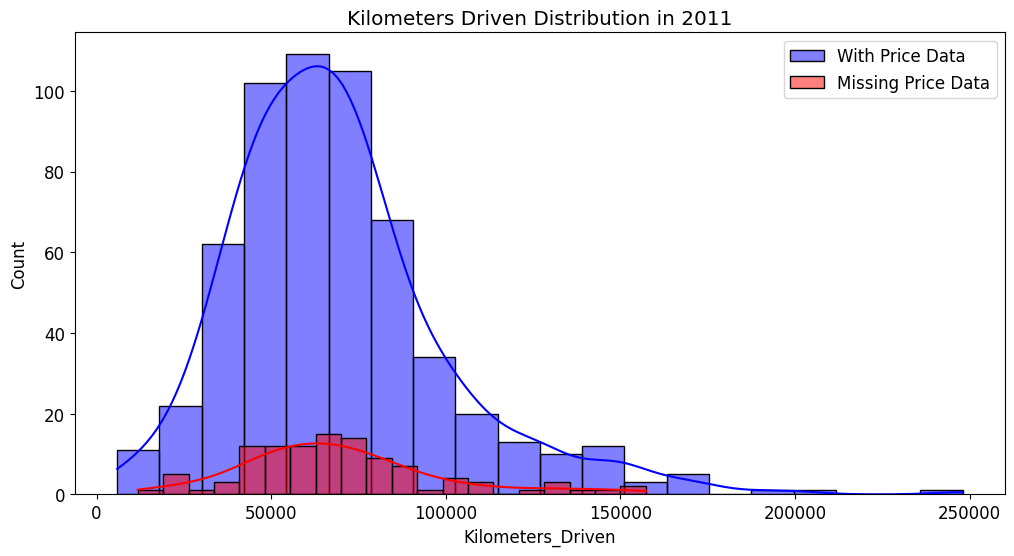

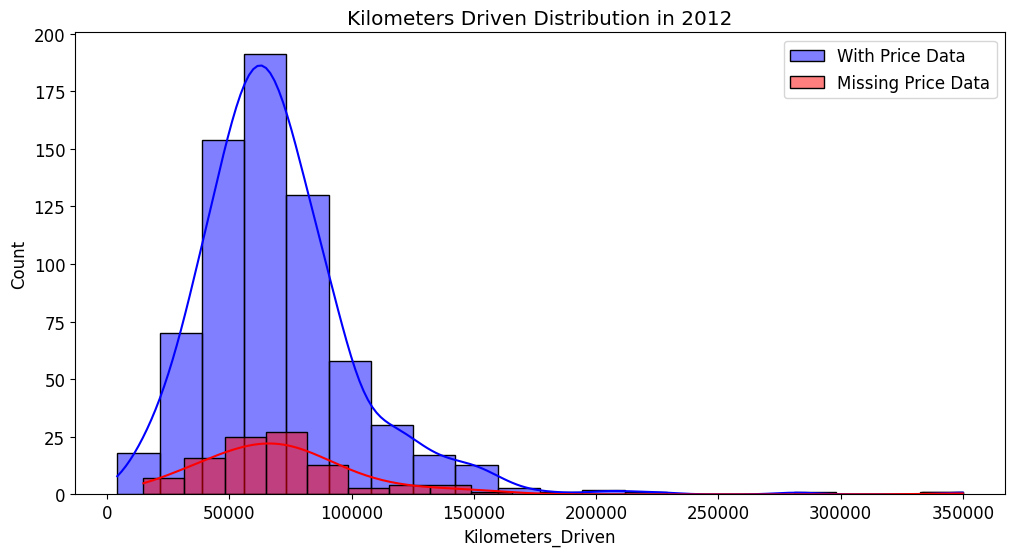

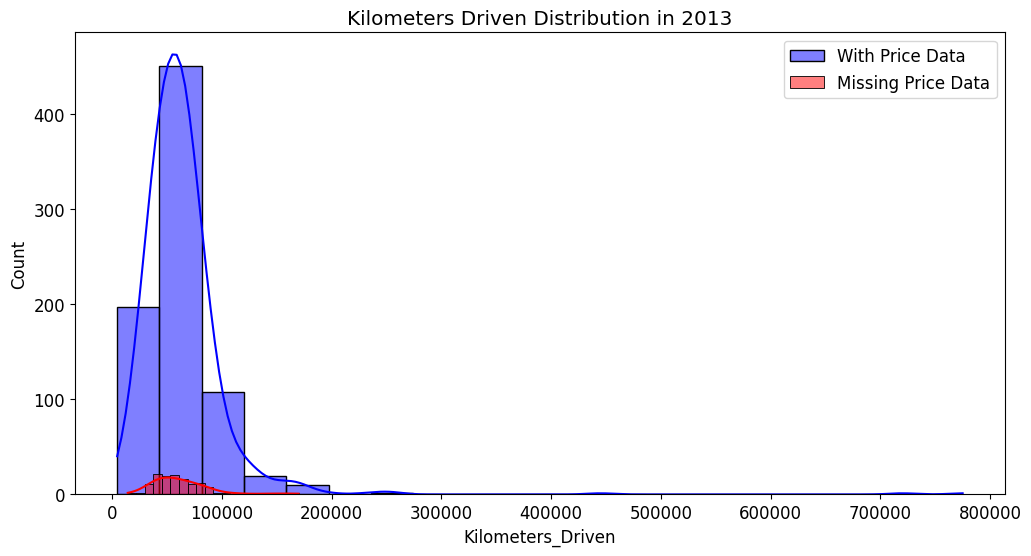

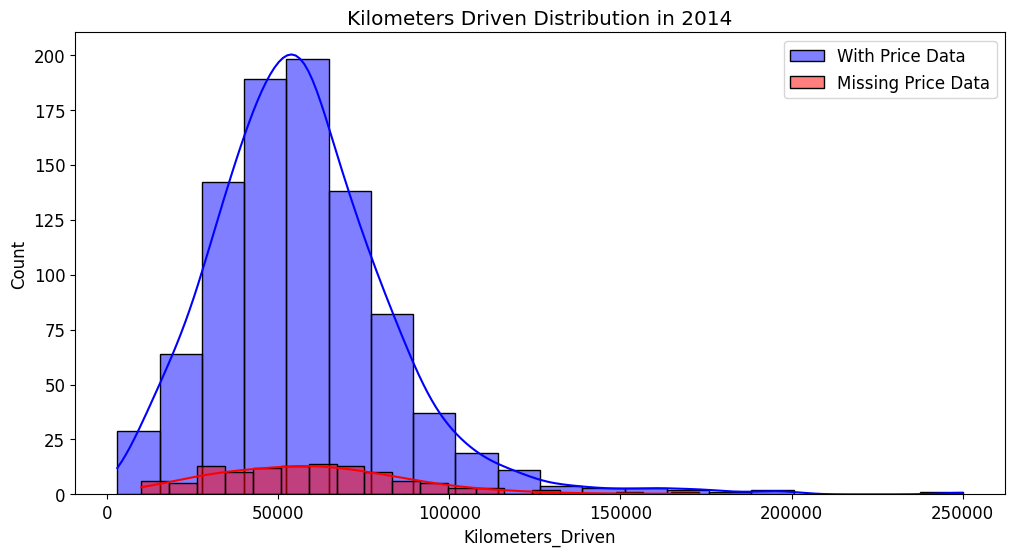

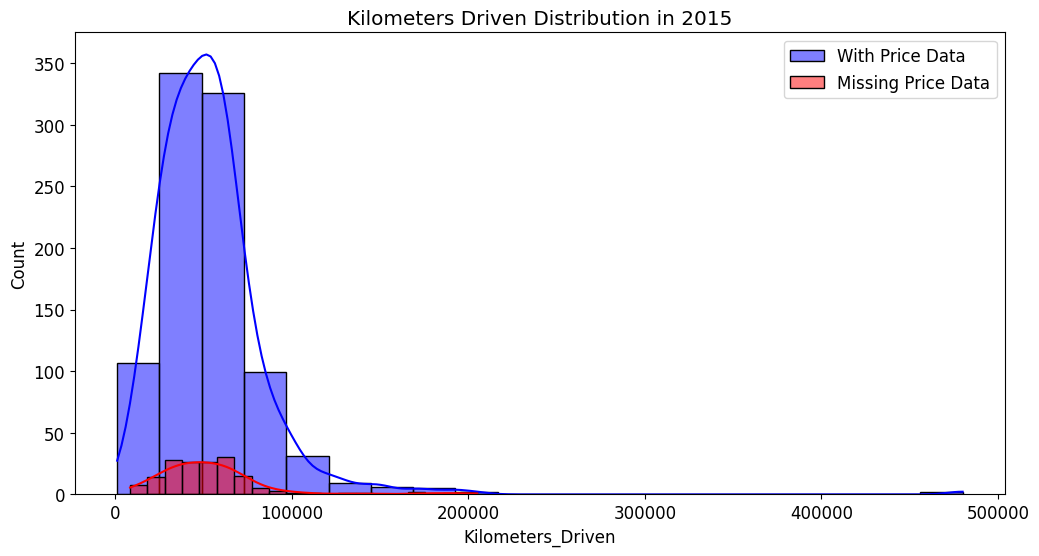

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

target_years = [2011, 2012, 2013, 2014, 2015]

for year in target_years:
    # 해당 연도의 전체 데이터와 결측치가 있는 데이터
    year_data = df[df['Year'] == year]
    missing_year_data = missing_price_df[missing_price_df['Year'] == year]

    # 그래프 그리기
    plt.figure(figsize=(12, 6))

    # 가격 데이터가 있는 경우의 'Kilometers_Driven' 분포
    sns.histplot(year_data['Kilometers_Driven'], color="blue", label="With Price Data", kde=True, bins=20, alpha=0.5)

    # 가격 결측치가 있는 경우의 'Kilometers_Driven' 분포
    sns.histplot(missing_year_data['Kilometers_Driven'], color="red", label="Missing Price Data", kde=True, bins=20, alpha=0.5)

    plt.title(f'Kilometers Driven Distribution in {year}')
    plt.legend()
    plt.show()


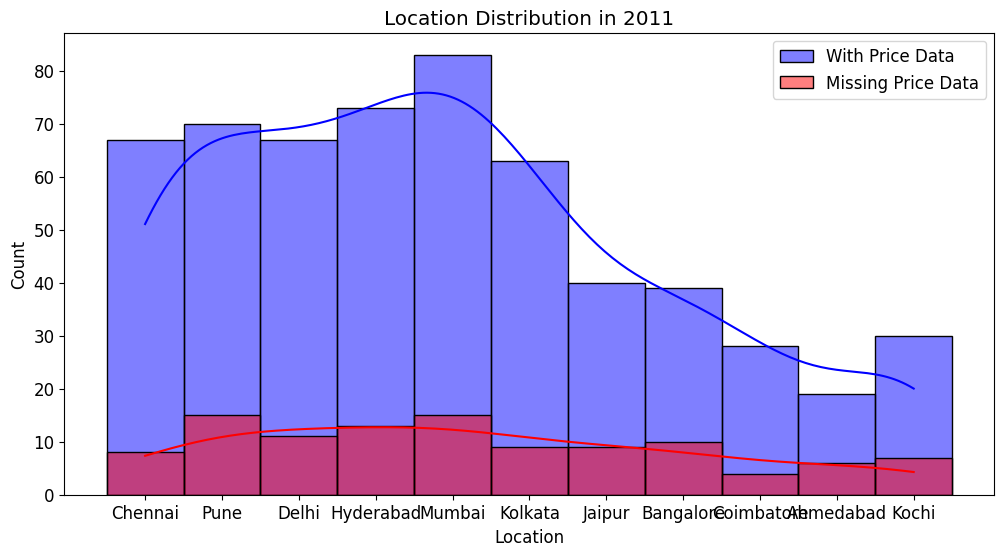

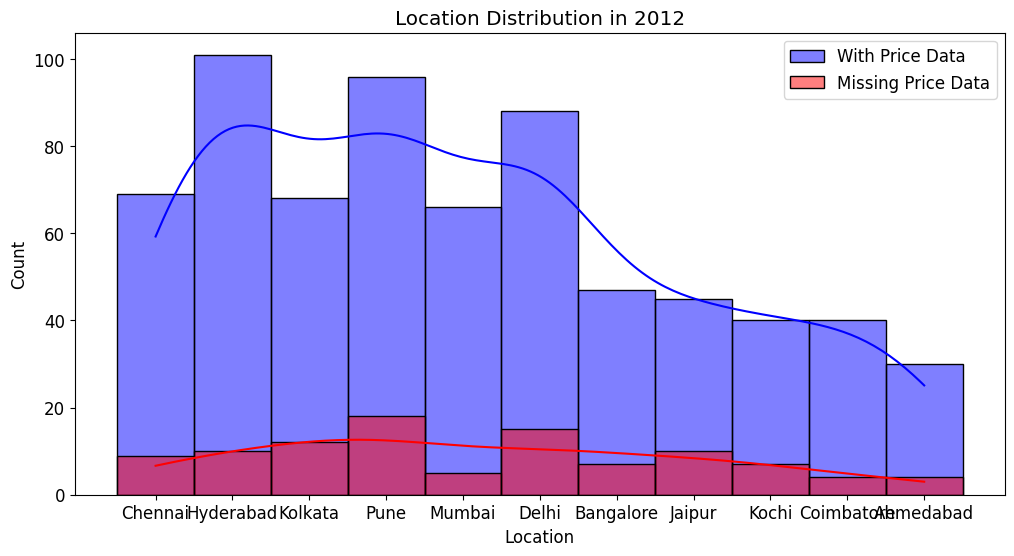

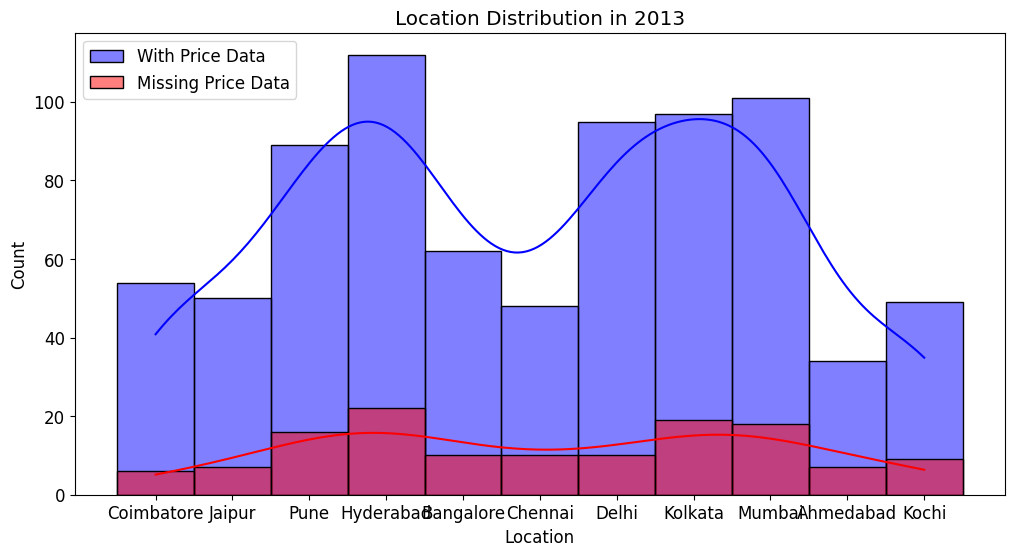

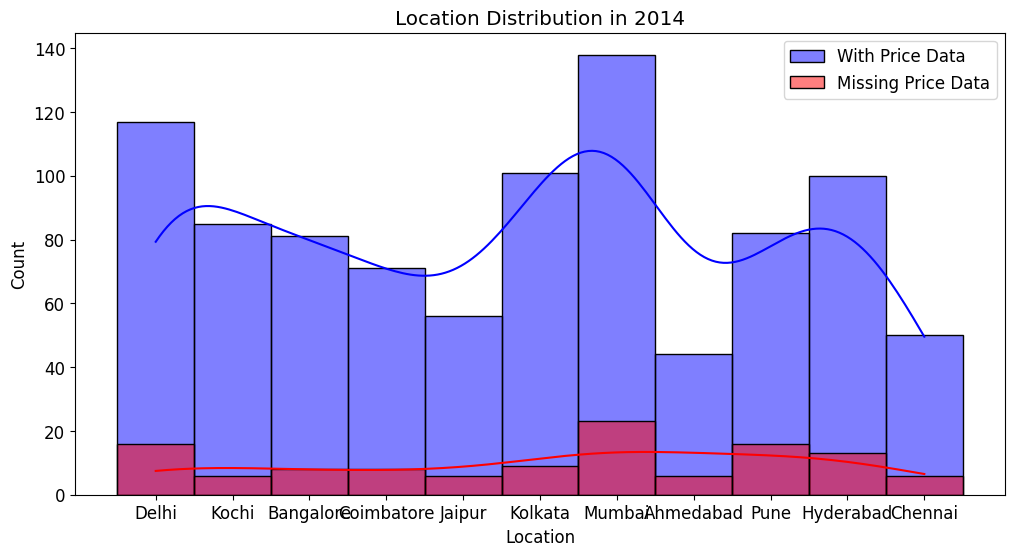

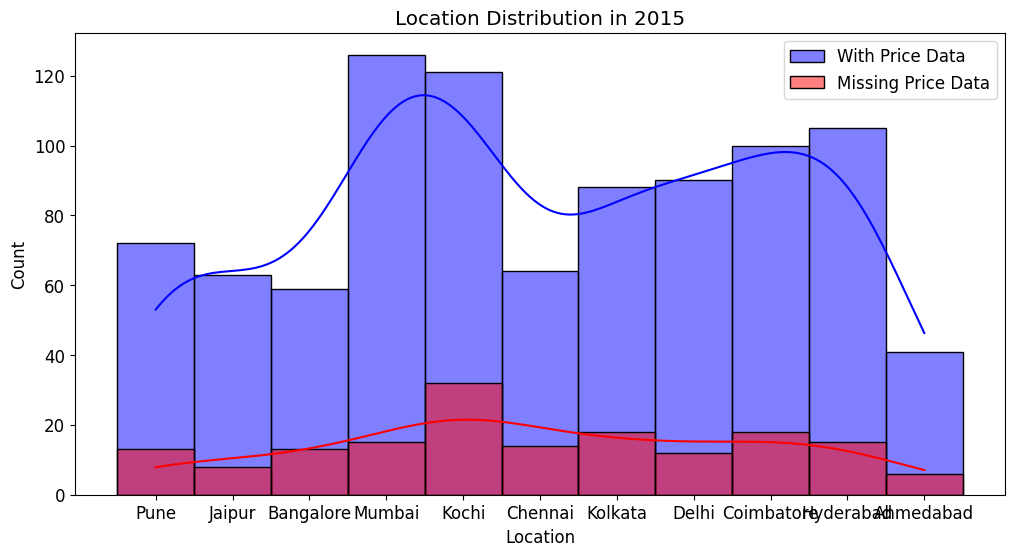

In [ ]:
# 예를 들어, 'Location' 변수와의 관계를 살펴봅니다.
for year in target_years:


    # 해당 연도의 전체 데이터와 결측치가 있는 데이터
    year_data = df[df['Year'] == year]
    missing_year_data = missing_price_df[missing_price_df['Year'] == year]

    # 그래프 그리기
    plt.figure(figsize=(12, 6))

    # 가격 데이터가 있는 경우의 'Kilometers_Driven' 분포
    sns.histplot(year_data['Location'], color="blue", label="With Price Data", kde=True, bins=20, alpha=0.5)

    # 가격 결측치가 있는 경우의 'Kilometers_Driven' 분포
    sns.histplot(missing_year_data['Location'], color="red", label="Missing Price Data", kde=True, bins=20, alpha=0.5)

    plt.title(f'Location Distribution in {year}')
    plt.legend()
    plt.show()

## EDA(데이터 분포/특징 확인)

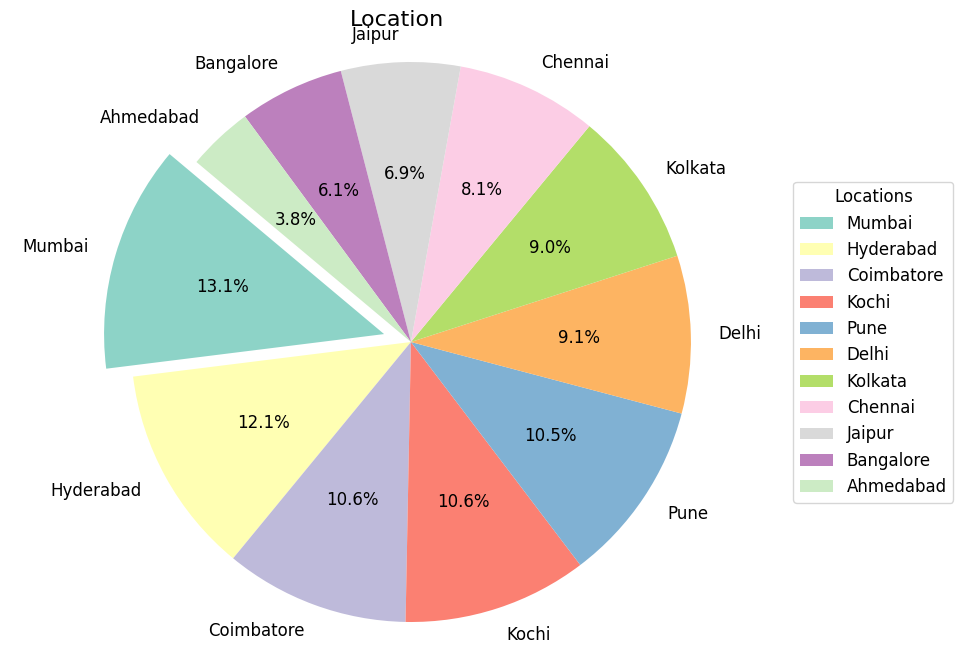

In [ ]:
# Location 파이 차트
# 'Location'의 값별 개수를 계산
location_counts = df['Location'].value_counts()

# 'Location'의 값별 개수를 계산하고, 큰 순서대로 정렬
location_counts = df['Location'].value_counts().sort_values(ascending=False)

# 각 조각에 대한 'explode' 설정: 가장 큰 조각을 강조
explode = [0.1 if i == 0 else 0 for i in range(len(location_counts))]

# 파이 차트 시각화
plt.figure(figsize=(10, 8))  # 차트의 크기 설정
plt.pie(location_counts, labels=location_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3", len(location_counts)), explode=explode)
plt.title('Location', fontsize=16)  # 차트 제목 설정
plt.axis('equal')  # 차트를 원형으로 만듭니다

# 범례 추가
plt.legend(location_counts.index, title="Locations", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

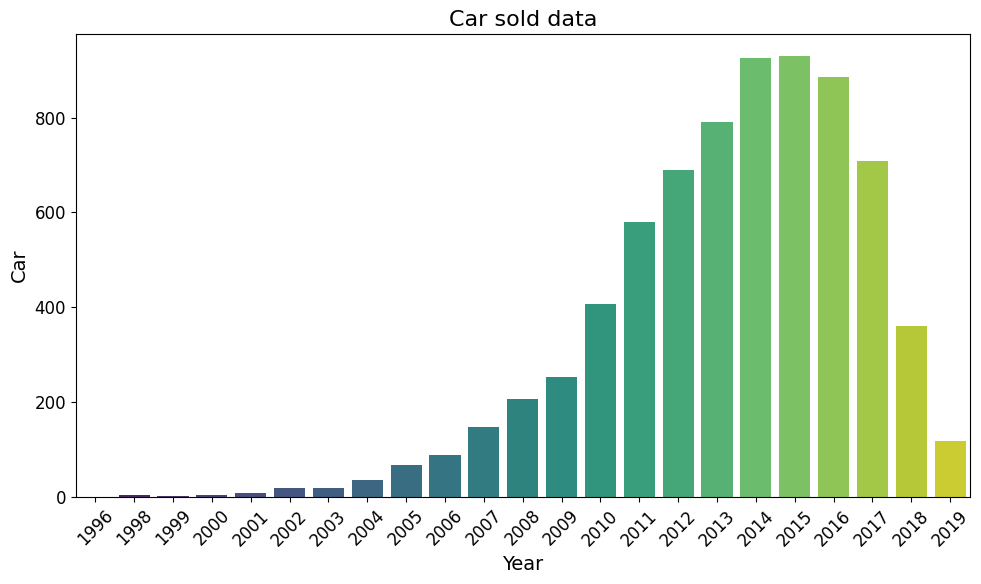

In [ ]:
#연도별 인도 중고차 판매 추이
# 연도별 카운트 계산
year_counts = df['Year'].value_counts().sort_index()

# 막대차트 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=year_counts.index, y=year_counts.values, palette='viridis')

plt.title('Car sold data', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Car', fontsize=14)
plt.xticks(rotation=45)  # x축 레이블 회전
plt.tight_layout()  # 레이아웃 조정

plt.show()

## location, brand group EDA

데이터 전처리가 완료된 데이터에 대해 location ,brand group에 대한 탐색적 데이터 분석

In [ ]:
#파일 불러오기
df = pd.read_csv('/content/drive/MyDrive/최강<포빅아A4>/인도 중고차 /박주형/df_car.csv')
df.head()

,Price,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Vehicle_Age,Brand_Group,city_location
0,2682.68,72000,2,1,1,26.60,998.0,58.16,5.0,18,14,1,2
1,19162.00,41000,0,1,1,19.67,1582.0,126.20,5.0,11,9,1,2
2,6898.32,46000,1,1,1,18.20,1199.0,88.70,5.0,10,13,1,3
3,9197.76,87000,0,1,1,20.77,1248.0,88.76,7.0,18,12,1,3
4,27194.71,40670,0,2,2,15.20,1968.0,140.80,5.0,1,11,2,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6992 entries, 0 to 6991
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              5994 non-null   float64
 1   Kilometers_Driven  6992 non-null   int64  
 2   Fuel_Type          6992 non-null   int64  
 3   Transmission       6992 non-null   int64  
 4   Owner_Type         6992 non-null   int64  
 5   Mileage            6992 non-null   float64
 6   Engine             6992 non-null   float64
 7   Power              6992 non-null   float64
 8   Seats              6992 non-null   float64
 9   Brand              6992 non-null   int64  
 10  Vehicle_Age        6992 non-null   int64  
 11  Brand_Group        6992 non-null   int64  
 12  city_location      6992 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 710.2 KB


In [ ]:
df.shape

(6992, 13)

In [ ]:
df['city_location'].unique()

array([2, 3, 4, 1])



## 지역을 동서남북으로 나누어 city_location 파생변수 생성
* east = ['Kolkata']
* west = ['Mumbai', 'Pune', 'Ahmedabad']
* south = ['Chennai', 'Coimbatore', 'Kochi', 'Hyderabad', 'Bangalore']
* north = ['Jaipur', 'Delhi']
* 동부 -> 1, 서부 -> 2, 남부 -> 3, 북부 -> 4

## 더미 변수화 전 변수에 대한 탐색적 분석

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/인도 중고차 /박주형/noprice.csv")
df.head()

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,2,1,1,26.60,998.0,58.16,5.0
1,Hyundai Creta 1.6 CRDi SX Option,Pune,19162.00,2015,41000,0,1,1,19.67,1582.0,126.20,5.0
2,Honda Jazz V,Chennai,6898.32,2011,46000,1,1,1,18.20,1199.0,88.70,5.0
3,Maruti Ertiga VDI,Chennai,9197.76,2012,87000,0,1,1,20.77,1248.0,88.76,7.0
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,27194.71,2013,40670,0,2,2,15.20,1968.0,140.80,5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5994 entries, 0 to 5993
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5994 non-null   object 
 1   Location           5994 non-null   object 
 2   Price              5994 non-null   float64
 3   Year               5994 non-null   int64  
 4   Kilometers_Driven  5994 non-null   int64  
 5   Fuel_Type          5994 non-null   int64  
 6   Transmission       5994 non-null   int64  
 7   Owner_Type         5994 non-null   int64  
 8   Mileage            5994 non-null   float64
 9   Engine             5994 non-null   float64
 10  Power              5994 non-null   float64
 11  Seats              5994 non-null   float64
dtypes: float64(5), int64(5), object(2)
memory usage: 562.1+ KB


In [ ]:
df.shape

(5994, 12)

### Price 로그화 취하고 극단치 버린 코드

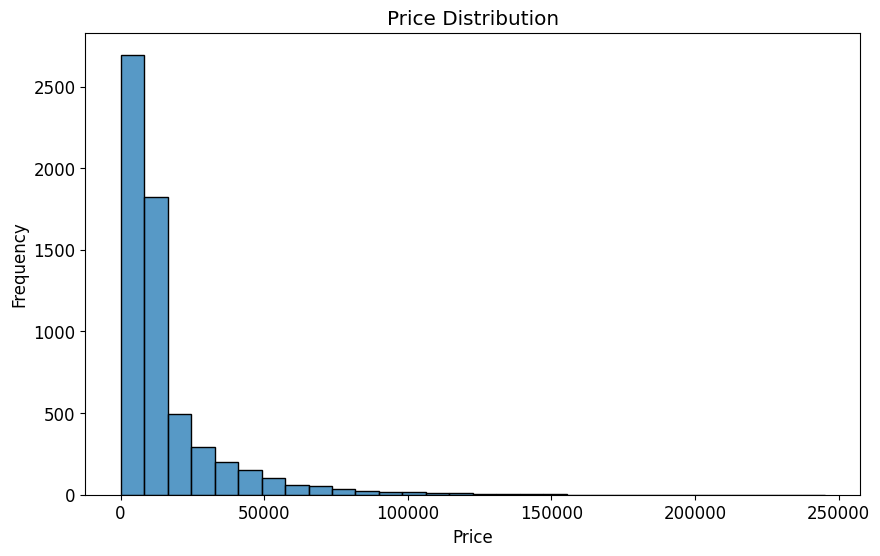

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Price 데이터에 대한 히스토그램
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=False, bins=30)  # KDE를 끄고, bins는 막대의 수를 조절
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


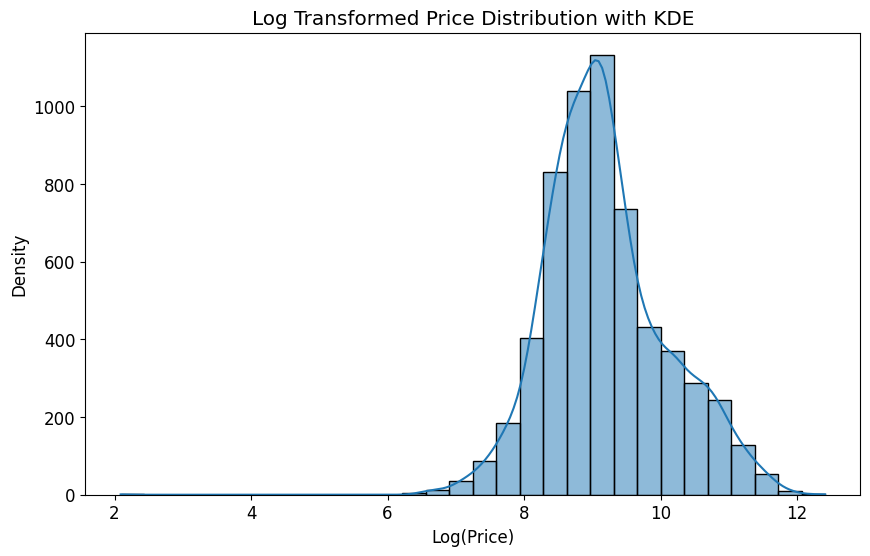

In [ ]:
# 가격 데이터에 로그 변환 적용 (0이거나 음수인 값이 없다고 가정)
df['log_price'] = np.log1p(df['Price'])  # log1p는 1을 더한 후 로그 변환을 수행

plt.figure(figsize=(10, 6))
sns.histplot(df['log_price'], kde=True, bins=30)  # 변환된 데이터에 대한 히스토그램 + KDE
plt.title('Log Transformed Price Distribution with KDE')
plt.xlabel('Log(Price)')
plt.ylabel('Density')
plt.show()


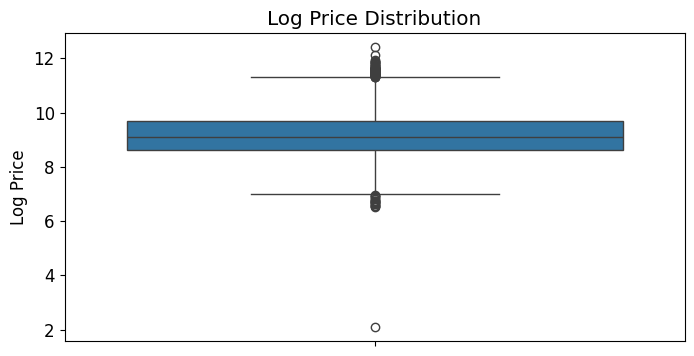

In [ ]:
# log_price에 대한 박스플롯 생성
plt.figure(figsize=(8, 4))  # 그래프 크기 설정
sns.boxplot(y=df['log_price'])
plt.title('Log Price Distribution')  # 그래프 제목 설정
plt.ylabel('Log Price')  # y축 레이블 설정
plt.show()

In [ ]:
# price 극단치 데이터 처리

# 'log_price' 열에 대한 Q1과 Q3 계산
Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)
IQR = Q3 - Q1

# IQR을 사용하여 이상치가 아닌 데이터의 범위 정의
lower_bound = Q1 - 1.5 * IQR

df= df[df['log_price'] >= lower_bound ]



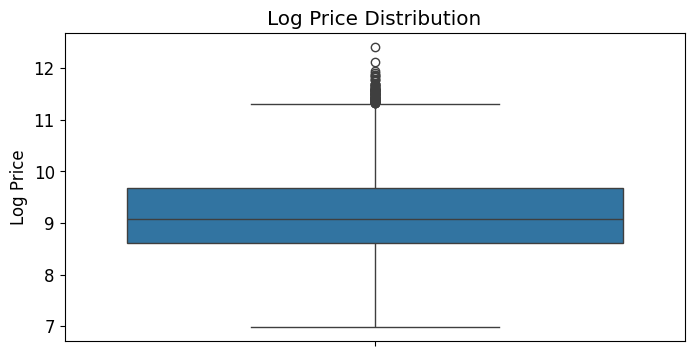

In [ ]:
# log_price에 대한 박스플롯 생성
plt.figure(figsize=(8, 4))  # 그래프 크기 설정
sns.boxplot(y=df['log_price'])
plt.title('Log Price Distribution')  # 그래프 제목 설정
plt.ylabel('Log Price')  # y축 레이블 설정
plt.show()

로그 전환한 가격 분포에서 극단적인 이상치를 제외했다.

### location 변수 영향력

In [ ]:
# 1. Location 변수의 분포 파악
print(df['Location'].value_counts())

Mumbai        807
Hyderabad     714
Kochi         672
Coimbatore    662
Pune          588
Delhi         566
Kolkata       543
Chennai       457
Jaipur        400
Bangalore     353
Ahmedabad     232
Name: Location, dtype: int64


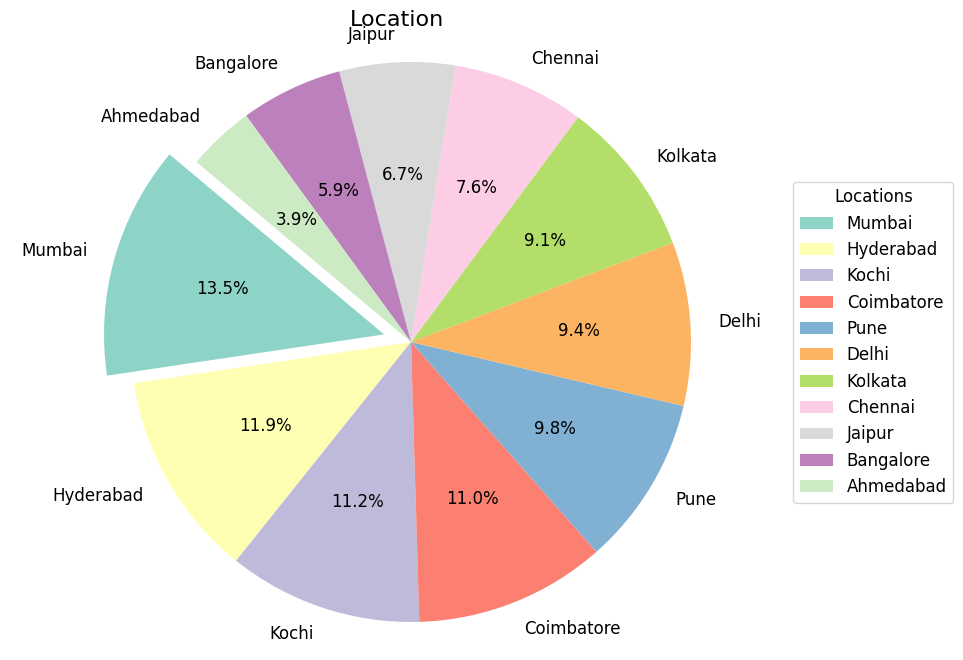

In [ ]:
# Location 파이 차트
# 'Location'의 값별 개수를 계산
location_counts = df['Location'].value_counts()

# 'Location'의 값별 개수를 계산하고, 큰 순서대로 정렬
location_counts = df['Location'].value_counts().sort_values(ascending=False)

# 각 조각에 대한 'explode' 설정: 가장 큰 조각을 강조
explode = [0.1 if i == 0 else 0 for i in range(len(location_counts))]

# 파이 차트 시각화
plt.figure(figsize=(10, 8))  # 차트의 크기 설정
plt.pie(location_counts, labels=location_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3", len(location_counts)), explode=explode)
plt.title('Location', fontsize=16)  # 차트 제목 설정
plt.axis('equal')  # 차트를 원형으로 만듭니다

# 범례 추가
plt.legend(location_counts.index, title="Locations", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

해석 :
위치 데이터를 살펴보면
Mumbai , Hderabad ,Coimbatore , Kochi 지역 4곳이 약 11% 이상의 판매 지분을 차지하고 있다.

지역 별 가격 분포를 살펴본 결과, 가격 분포에 차이가 있는 것으로 나타난다. 또한 자동차가 저가형부터 고가형까지 가격대가 다양하다는 특성도 많은 이상치가 나타나는 것에 영향을 미친 것으로 보인다.

따라서 지역 변수를 살펴볼 필요가 있다.

다만 변수를 좀 더 단순화해 더 지역 패턴을 찾아보기로 결정했다.

In [ ]:
#지역을 동서남북으로 나누어 city_location 파생변수 생성
east = ['Kolkata']
west = ['Mumbai', 'Pune', 'Ahmedabad']
south = ['Chennai', 'Coimbatore', 'Kochi', 'Hyderabad', 'Bangalore']
north = ['Jaipur', 'Delhi']

def city2ewsn(city):
    if city in east:
        return 'east'
    elif city in west:
        return 'west'
    elif city in south:
        return 'south'
    elif city in north:
        return 'north'

df['city_location'] = df.Location.apply(city2ewsn)

In [ ]:
# 동부 -> 1, 서부 -> 2, 남부 -> 3, 북부 -> 4
df['city_location'] = df['city_location'].replace('east', 1)
df['city_location'] = df['city_location'].replace('west', 2)
df['city_location'] = df['city_location'].replace('south', 3)
df['city_location'] = df['city_location'].replace('north', 4)

In [ ]:
df['city_location'] = df['city_location'].replace({1: 'east', 2: 'west', 3: 'south', 4: 'north'})

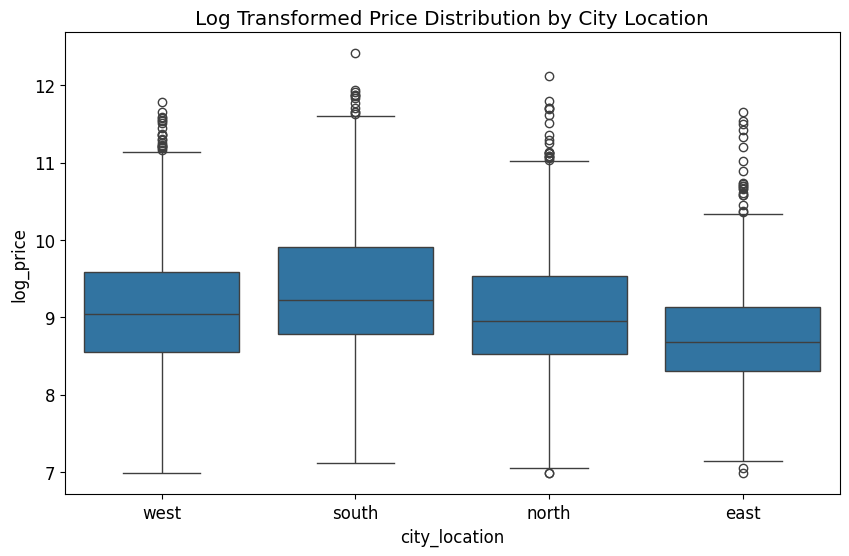

In [ ]:
# 2. 로그 변환된 가격에 대한 박스플롯 생성
plt.figure(figsize=(10, 6))
sns.boxplot(x='city_location', y='log_price', data=df)
plt.title('Log Transformed Price Distribution by City Location')
plt.show()

동서남북 지역 간의 가격 분포는 상당히 유사한 특징을 보여줍니다. 각 지역별 박스플롯의 중앙값, 분포 범위, 그리고 수염의 길이가 비슷하여, 지역별로 가격에 대한 중대한 차이가 존재하지 않는 것으로 관찰됩니다. 이는 지역적 위치가 가격 결정에 있어 주요한 변별 요소가 아님을 시사합니다.



In [ ]:
df.head(1)

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,city_location,log_price,Brand,Brand_Group
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,2,1,1,26.6,998.0,58.16,5.0,west,7.894944,Maruti,GeneralBrands


In [ ]:
# city_location 변수와  price 변수 간의 상관성  분석
# 한 개 명목변수(집단 여러개) - 한 개 목표변수 => anova

from scipy.stats import kruskal


# 각 위치별 가격 데이터 준비
east_prices = df[df['city_location'] == 'east']['log_price']
west_prices = df[df['city_location'] == 'west']['log_price']
south_prices = df[df['city_location'] == 'south']['log_price']
north_prices = df[df['city_location'] == 'north']['log_price']

from scipy.stats import normaltest
#정규성 검정
stat, p = normaltest(east_prices)
print('East Prices - D\'Agostino\'s K^2 Test: Statistics=%.3f, p=%.3f' % (stat, p))
stat, p = normaltest(west_prices)
print('West Prices - D\'Agostino\'s K^2 Test: Statistics=%.3f, p=%.3f' % (stat, p))

stat, p = normaltest(south_prices)
print('South Prices - D\'Agostino\'s K^2 Test: Statistics=%.3f, p=%.3f' % (stat, p))

stat, p = normaltest(north_prices)
print('North Prices - D\'Agostino\'s K^2 Test: Statistics=%.3f, p=%.3f' % (stat, p))


East Prices - D'Agostino's K^2 Test: Statistics=72.627, p=0.000
West Prices - D'Agostino's K^2 Test: Statistics=38.649, p=0.000
South Prices - D'Agostino's K^2 Test: Statistics=103.459, p=0.000
North Prices - D'Agostino's K^2 Test: Statistics=39.077, p=0.000


정규성 검정 결과는 모든 지역(동, 서, 남, 북)에 대한 가격 데이터가 정규 분포를 따르지 않기 때문에 세 개 이상 그룹 간의 분포 차이를 평가하는 비모수 통계 기법을 사용하겠다.

In [ ]:
from scipy.stats import kruskal
# 각 'city_location' 범주별로 가격 데이터를 분리합니다.
groups = df.groupby('city_location')['log_price'].apply(list)

# Kruskal-Wallis H 검정을 수행합니다.
stat, p_val = kruskal(*groups)
print(f"Kruskal-Wallis H 검정 결과: 통계량={stat}, p-값={p_val}")

Kruskal-Wallis H 검정 결과: 통계량=295.07725756719293, p-값=1.1565381737317104e-63


비모수 검정 결과, p-value가 0.05이하이므로, 유의한 변수로 선정할 수 있다.

### 브랜드 변수 영향력 확인(변수 삭제)

In [ ]:
top_10_names = df['Name'].value_counts().head(10)
print(top_10_names)
# 가장 인기있는 브랜드 및 모델 확인

Mahindra XUV500 W8 2WD      48
Maruti Swift VDI            46
Honda City 1.5 S MT         33
Maruti Swift Dzire VDI      33
Maruti Swift VDI BSIV       31
Hyundai i10 Sportz          30
Maruti Ritz VDi             29
Hyundai Grand i10 Sportz    27
Honda Amaze S i-Dtech       27
Maruti Wagon R LXI          25
Name: Name, dtype: int64


In [ ]:
len(np.unique(list(df.Name)))

1868

In [ ]:
df['Brand'] = df.Name.apply(lambda x:x.split()[0])

In [ ]:
brand_count = df['Brand'].nunique()
print('차 브랜드 개수 : {}'.format(brand_count))

unique_brands = df['Brand'].unique()
print(unique_brands)

차 브랜드 개수 : 30
['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra' 'Ford'
 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda' 'Mini' 'Fiat'
 'Jeep' 'Smart' 'Ambassador' 'ISUZU' 'Force' 'Bentley' 'Lamborghini']


In [ ]:
brand_groups = { #브랜드 등급별로 분류
    'GeneralBrands': ['Maruti', 'Hyundai', 'Honda', 'Toyota', 'Nissan', 'Tata', 'Mitsubishi', 'Renault', 'Mahindra',
                       'Chevrolet', 'Skoda', 'Fiat', 'Jeep', 'Ambassador', 'ISUZU', 'Force', 'Hindustan','Ford'], #일반 브랜드
    'PremiumBrands': ['Audi', 'Volkswagen', 'Porsche', 'Mercedes-Benz', 'BMW', 'Jaguar', 'Volvo', 'Land', 'Bentley', 'Lamborghini'], #프리미엄 브랜드
    'CompactBrands': ['Datsun', 'Mini', 'Smart', 'OpelCorsa'] #소형 브랜드
}

df['Brand_Group'] = df['Brand'].map({brand: group for group, brands in brand_groups.items() for brand in brands})

In [ ]:
df['Brand_Group'].unique()

array(['GeneralBrands', 'PremiumBrands', 'CompactBrands'], dtype=object)

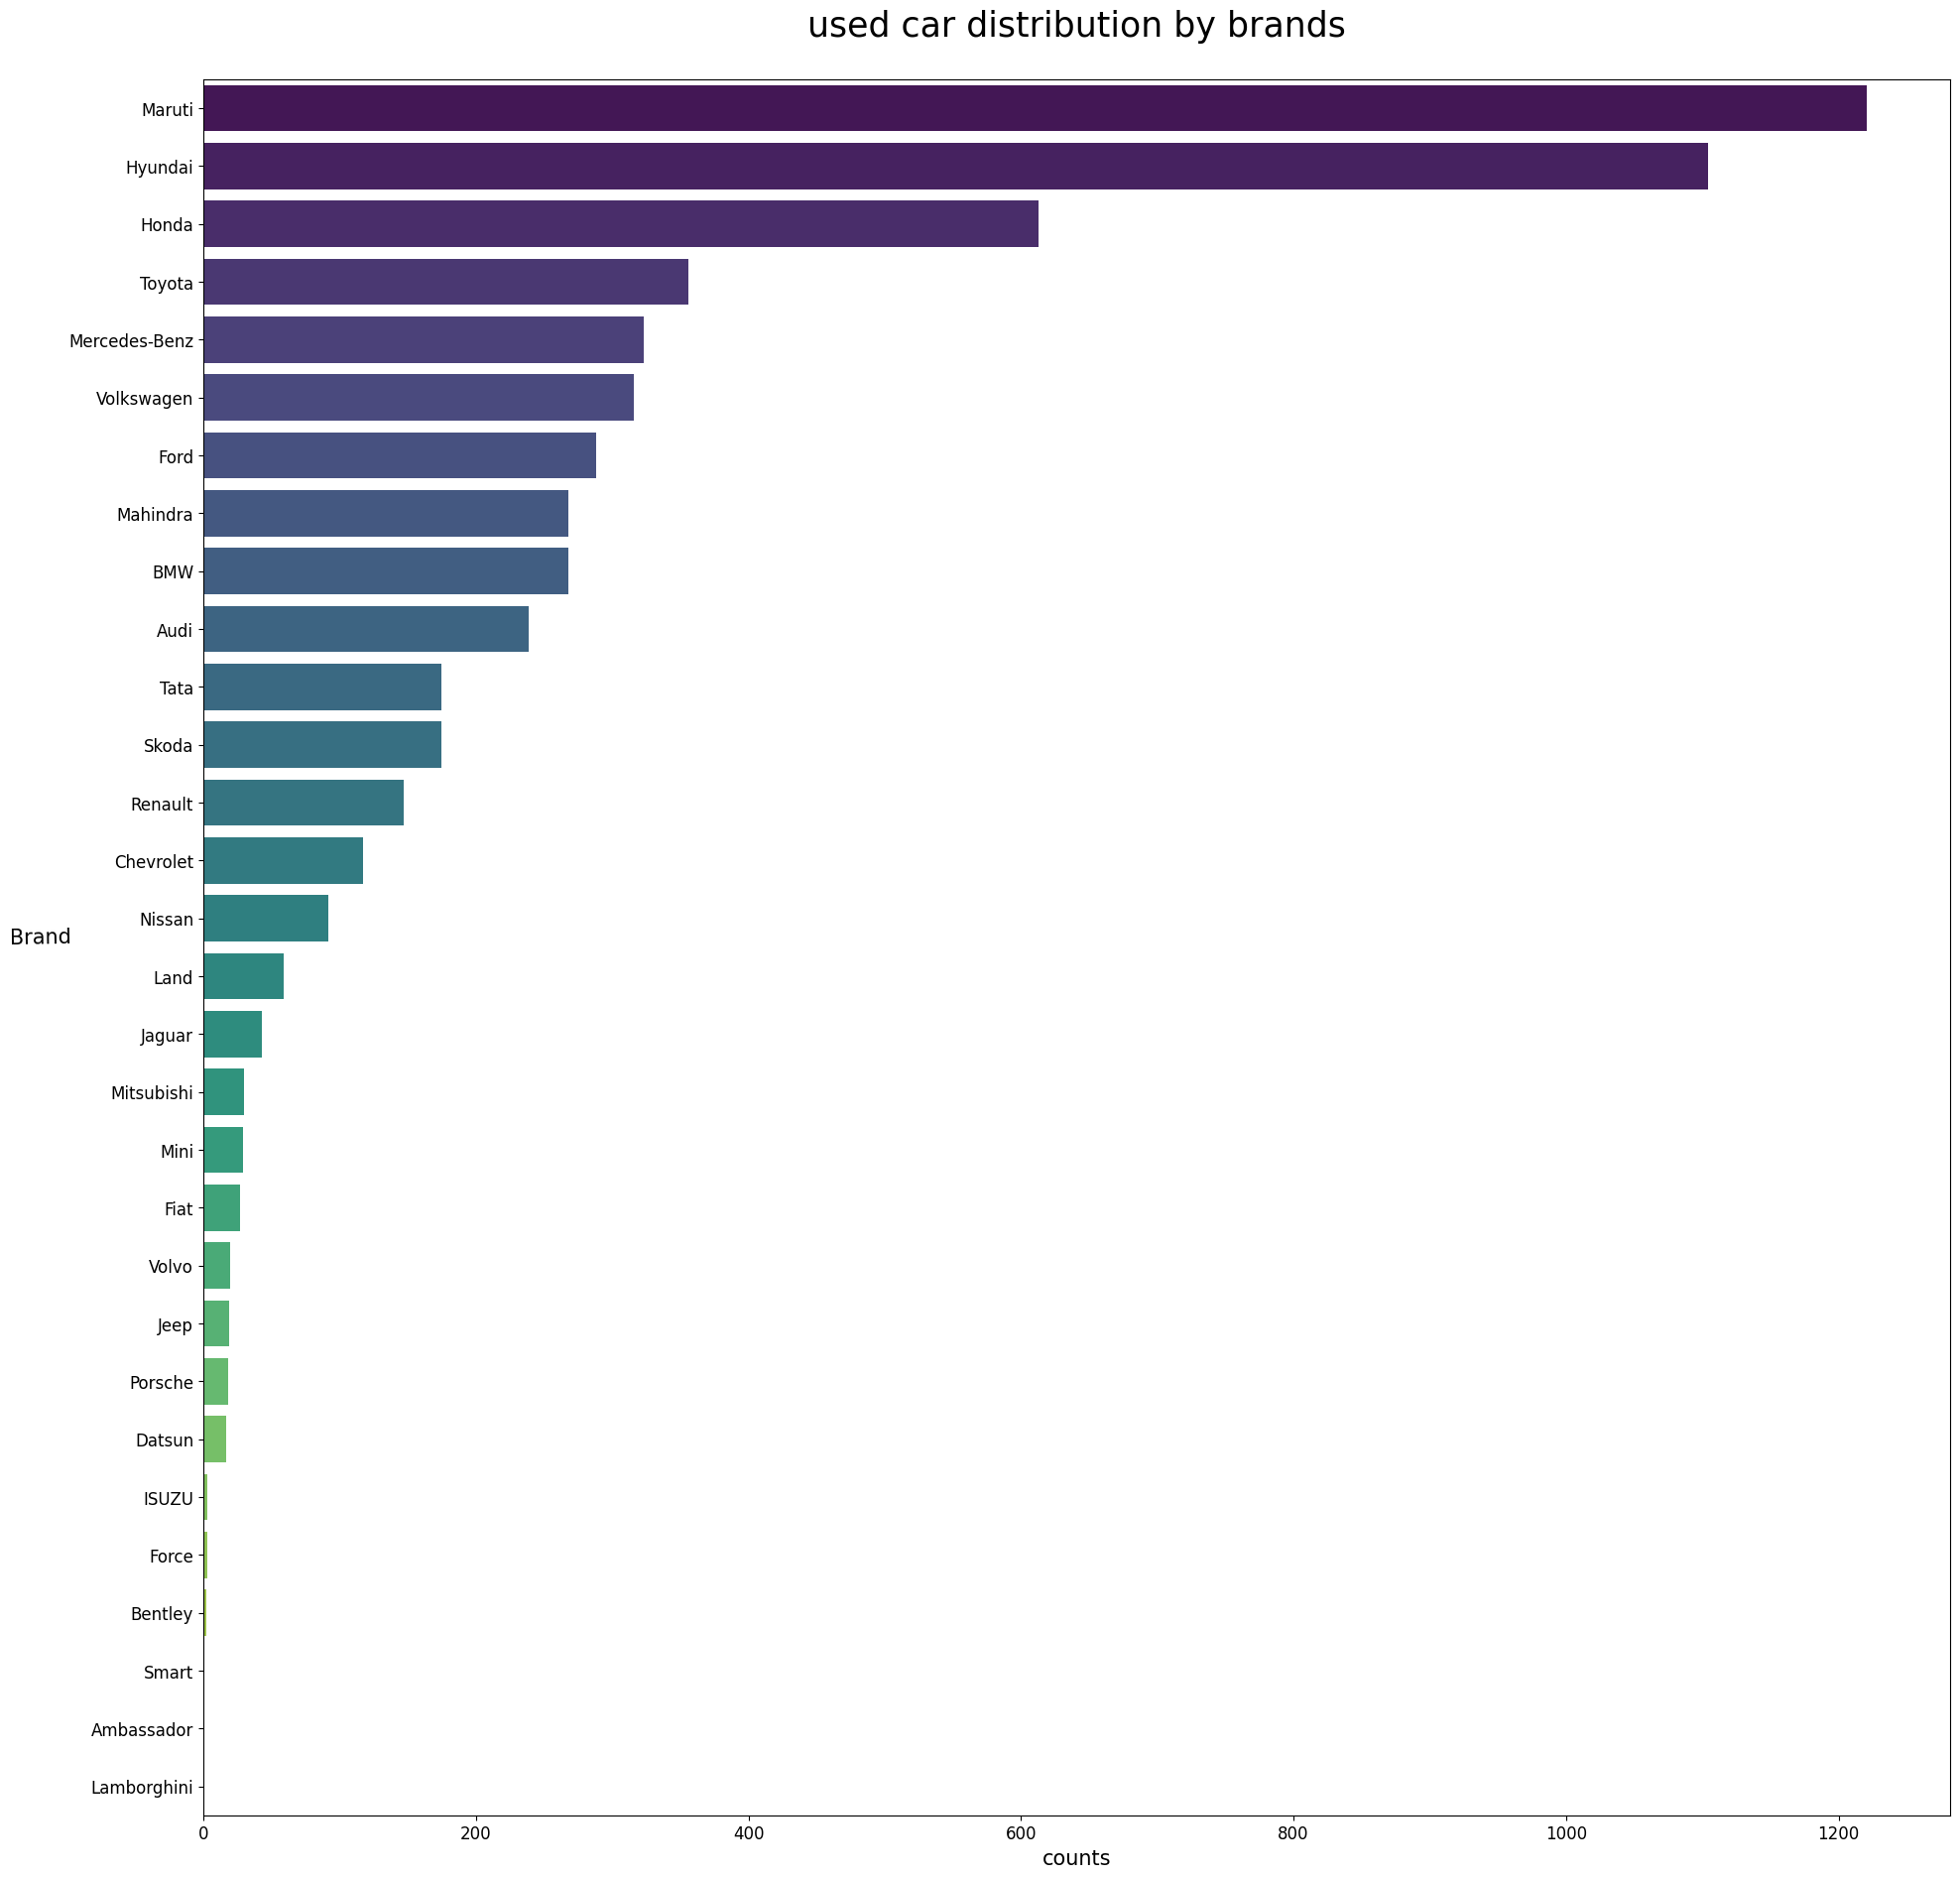

In [ ]:
plt.figure(figsize=(50,50))
plt.subplot(221)

sns.barplot(data=pd.DataFrame(df['Brand'].value_counts()).T, palette='viridis', ci=False, orient='h')

plt.title('used car distribution by brands', fontsize=25, y=1.02)
plt.xlabel('counts', fontsize=15)
plt.ylabel('Brand', fontsize=15, rotation=1, labelpad=20)

plt.show()

상위 5개 브랜드

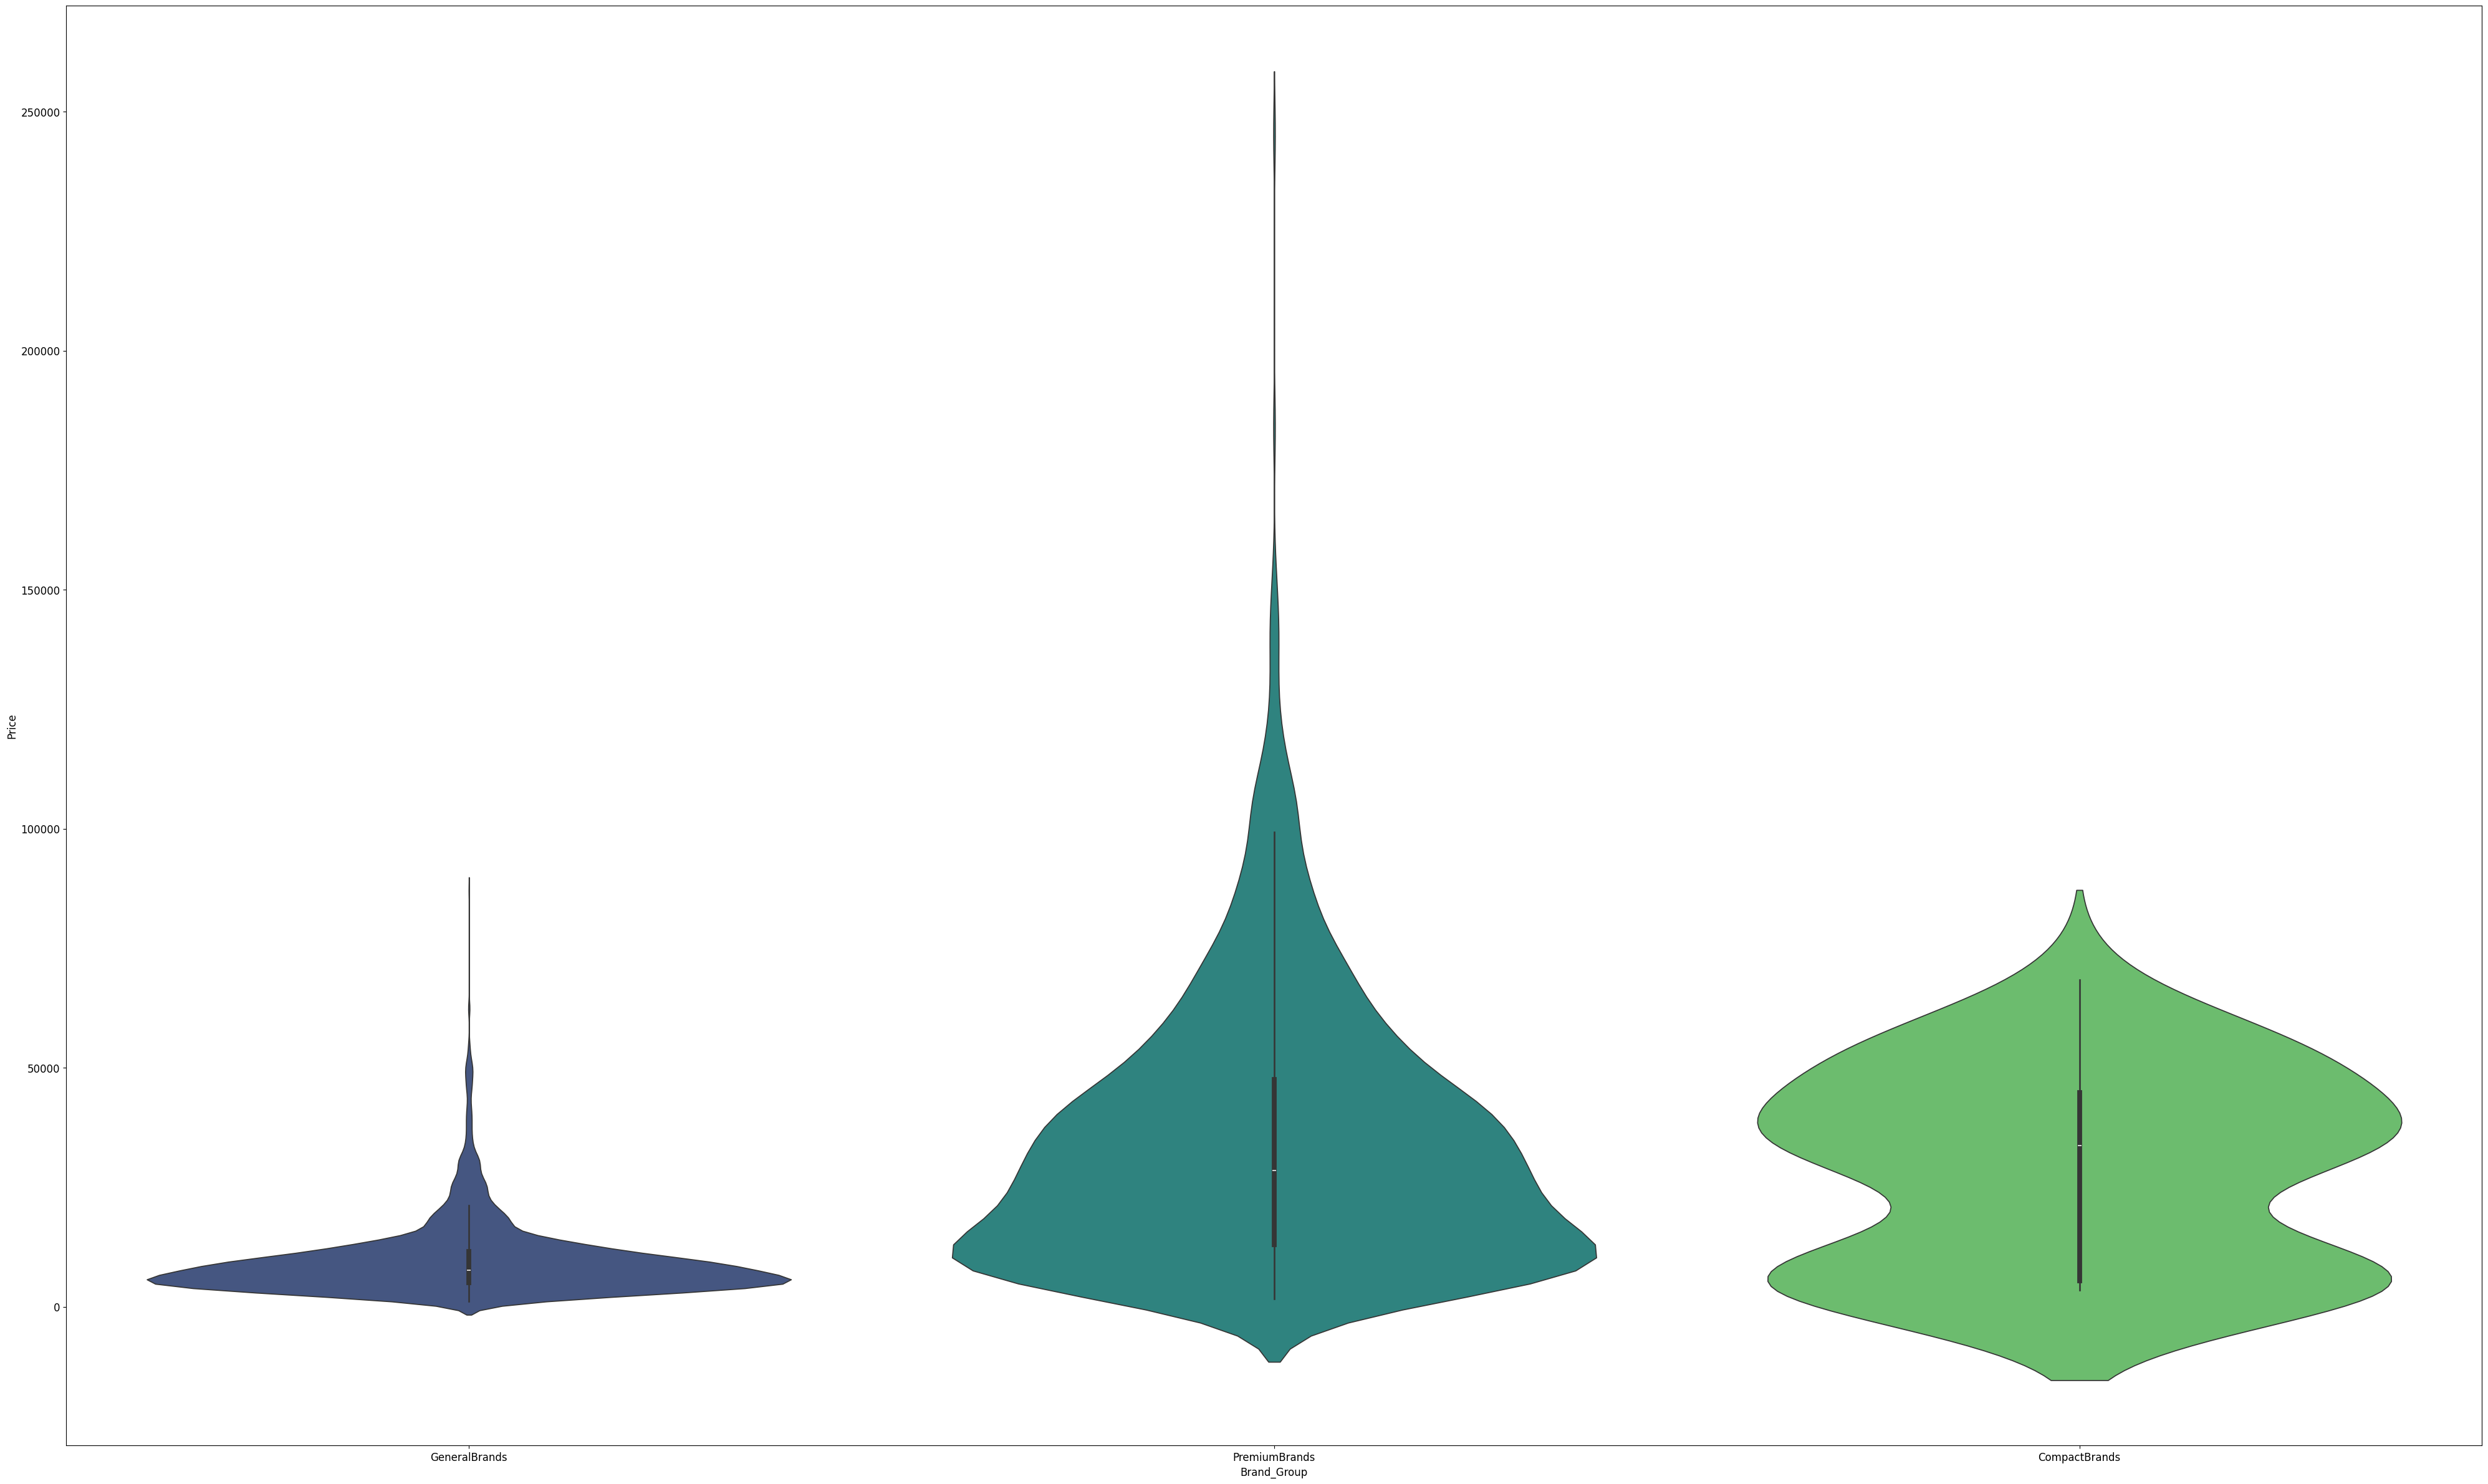

In [ ]:
plt.figure(figsize=(50,30))
sns.violinplot(data=df, x="Brand_Group", y="Price", palette='viridis')
plt.show()

### 브랜드 변수 검정(변수 삭제)

In [ ]:
df=['']

In [ ]:
df['Brand_Group'].info()


<class 'pandas.core.series.Series'>
Int64Index: 5975 entries, 0 to 5992
Series name: Brand_Group
Non-Null Count  Dtype 
--------------  ----- 
5975 non-null   object
dtypes: object(1)
memory usage: 222.4+ KB


In [ ]:
df['Brand_Group'].unique()

array(['GeneralBrands', 'PremiumBrands', 'CompactBrands'], dtype=object)

In [ ]:
from scipy.stats import shapiro, normaltest

# 각 'Brand_Group' 범주별로 'Log_price' 데이터의 정규성 검정
for brand in df['Brand_Group'].unique():
    stat, p = shapiro(df[df['Brand_Group'] == brand]['log_price'])
    print(f"Shapiro test for {brand}: Statistics={stat}, p-value={p}")

# 또는
# for brand in df['Brand_Group'].unique():
#    stat, p = normaltest(df[df['Brand_Group'] == brand]['Log_price'])
#    print(f"Normal test for {brand}: Statistics={stat}, p-value={p}")


Shapiro test for GeneralBrands: Statistics=0.9966647624969482, p-value=1.1518809017729836e-08
Shapiro test for PremiumBrands: Statistics=0.972531795501709, p-value=6.100155103272442e-15
Shapiro test for CompactBrands: Statistics=0.8098261952400208, p-value=2.654219088071841e-06


모든 그룹의 p-value 값이 통상적인 유의 수준(0.05)보다 훨씬 낮습니다. 이는 GeneralBrands, PremiumBrands, CompactBrands 모두의 데이터가 통계적으로 유의미하게 정규 분포를 따르지 않음을 의미합니다. 정규성 가정이 충족되지 않았기 때문에, 이 경우 ANOVA 같은 정규성을 가정하는 통계적 방법보다는 비모수적인 방법을 고려하는 것이 적절할 수 있습니다.




In [ ]:
from scipy.stats import kruskal

# 'Brand_Group' 별로 'Log_price' 데이터를 추출
data_groups = []
for brand_group in df['Brand_Group'].unique():
    group_prices = df[df['Brand_Group'] == brand_group]['log_price']
    data_groups.append(group_prices)

# Kruskal-Wallis H 검정 수행
stat, p_val = kruskal(*data_groups)
print(f"Kruskal-Wallis H 검정 결과: 통계량={stat}, p-값={p_val}")


Kruskal-Wallis H 검정 결과: 통계량=1453.7192607176114, p-값=0.0


In [ ]:
즉, 분석된 Brand_Group 내의 적어도 한 그룹의 Log_price 분포가 다른 그룹들과 통계적으로 유의미한 차이를 보인다는 것을 의미합니다.